# Импорт библиотек и загрузка данных

In [51]:
import os
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import seaborn as sns
import pandas as pd

image_path = [i for i in Path("../data/images/test").glob("*") if i.suffix in (".jpg", ".png")]


def get_ppi(img_path):
    ppis = []
    for img in img_path:
        with Image.open(img) as im:
            if 'dpi' in im.info:
                ppis.append(im.info['dpi'][0])
            else:
                # TODO fallback. Set manual pixel spacing that checks ratio of dims
                # and set ppi according to A standard sizes
                ppis.append(300)
            
    return ppis

def get_dimensions(img_path):
    dimensions = [] # Разрешения изображений
    for img in img_path:
        with Image.open(img) as im:
            dimensions.append(im.size)
    return dimensions

# Распределение разрешений. Распределение соотношения сторон. 

Все тестовые изображения были размечены вручную через labelimg, поэтому проверка аннотаций bbox на этапе EDA была опущена.

Количество тестовых изображений 49


/home/saparch/playground/.venv/lib/python3.12/site-packages/PIL/Image.py:3451: DecompressionBombWarning: Image size (90512000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
/home/saparch/playground/.venv/lib/python3.12/site-packages/PIL/Image.py:3451: DecompressionBombWarning: Image size (91663071 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


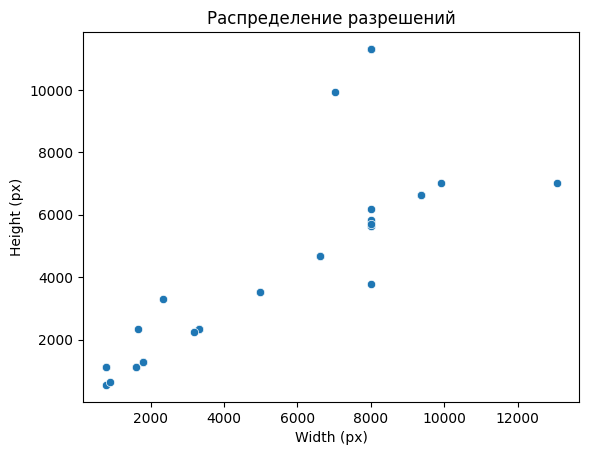

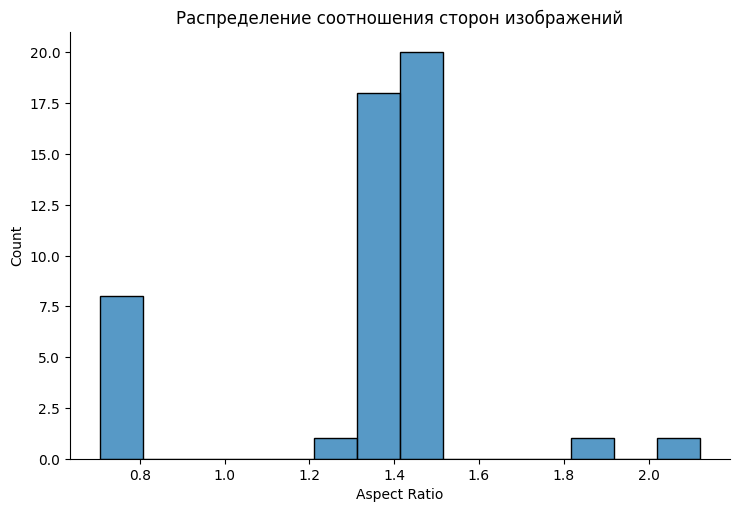

In [55]:
ppi = get_ppi(image_path)
dims = get_dimensions(image_path)
widths, heights = zip(*dims)

print("Количество тестовых изображений", len(image_path))

sns.scatterplot(x=widths, y=heights)
plt.title("Распределение разрешений")
plt.xlabel("Width (px)")
plt.ylabel("Height (px)")
plt.show()

data = pd.DataFrame({"aspect_ratio": np.array(widths) / np.array(heights)})
sns.displot(data=data, x="aspect_ratio", kind="hist", aspect=1.5)
plt.title("Распределение соотношения сторон изображений")
plt.xlabel("Aspect Ratio")
plt.ylabel("Count")
plt.show()

Как мы видим из распределения сторон. Большинство тестовых изображений в пределах  $1.4 \approx \sqrt2$ для горизонтальных чертежей и в пределах $0.7$ для вертикальных, что соответстует стандарту ISO 216. 